In [1]:
import pandas as pd

In [3]:
df = pd.read_csv('naukri_data_analyst_jobs.csv')

In [5]:
print(df.shape)

(998, 8)


In [9]:
df.head()

,title,company,experience,salary,location,description,skills,posted
0,"Data Steward, Analyst/Associate",Goldman Sachs,0-3 Yrs,NaN,Bengaluru,SKILLS & EXPERIENCE WE ARE LOOKING FOR Relevan...,"Automation, Data management, Wealth management...",3+ weeks ago
1,Data Analyst,Wonderla Holidays,3-5 Yrs,"50,000-80,000 PA",Bengaluru,Preferred candidate profile,"D2C, Google Data Studio, R, Google Analytics, ...",1 day ago
2,Looking For immediate joiners - Lab Data Analy...,IQVIA,2-4 Yrs,NaN,Hybrid - Kolkata,Job Title : Lab Data Analyst-Python Programmin...,"PYTHON PROGRAMMING, Pyspark, Logical Approach,...",5 days ago
3,Data Analyst - 10th April - Virtual Interview ...,Tata Consultancy Services,7-12 Yrs,NaN,"India, Bengaluru, Mumbai (All Areas)","Hands-on experience with Databricks, Amazon Re...","Power BI, Tableau, Data Analytics, Analytics, ...",3 days ago
4,"Auth Fraud Supervisor- Data Analyst, UIDAI/Ben...",National Institute for Smart Government (NISG),6-10 Yrs,13-23 Lacs PA,Bengaluru,Education Qualification:• B. Tech /MCA /Engine...,"Data Analysis, Fraud Management, Python, SQL, ...",1 week ago


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 998 entries, 0 to 997
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   title        998 non-null    object
 1   company      998 non-null    object
 2   experience   973 non-null    object
 3   salary       130 non-null    object
 4   location     993 non-null    object
 5   description  978 non-null    object
 6   skills       978 non-null    object
 7   posted       998 non-null    object
dtypes: object(8)
memory usage: 62.5+ KB


In [13]:
print(df.duplicated().sum())

5


In [15]:
df.isnull().sum()

title            0
company          0
experience      25
salary         868
location         5
description     20
skills          20
posted           0
dtype: int64

In [21]:
# 1 - REMOVE DUPLICATE ROWS

print(df.duplicated().sum())
df = df.drop_duplicates()
df = df.reset_index(drop=True)
print(df.duplicated().sum())

5
0


In [81]:
# 2 - HANDLE MISSING VALUES

print(df.isnull().sum())

# drop rows missing essential info
df = df.dropna(subset=['location'])

# fill missing text columns with 'Not Mentioned'
df['experience'] = df['experience'].fillna('Not Mentioned')
df['description'] = df['description'].fillna('Not Mentioned')
df['skills'] = df['skills'].fillna('Not Mentioned')
df['skills'] = df['skills'].str.title()

# SKILL NAME MAPPING: some skills are written differently by different
# companies but mean the same thing, e.g. 'Sql' vs the standard 'SQL'.
skill_mapping = {
    'Sql': 'SQL', 'Bi': 'Business Intelligence', 'Sap': 'SAP',
    'Sas': 'SAS', 'Etl': 'ETL', 'Kpi': 'KPI', 'Mysql': 'MySQL',
    'Power Bi': 'Power BI','Data Analytics': 'Data Analysis',
}

# REMOVE GENERIC/FILLER TAGS: too vague to count as a real skill,
# or not a skill at all ('Data Analyst' is a job title).
generic_skills_to_remove = [
    'Data', 'Analytics', 'Analytical', 'Analysis', 'Management',
    'Operations', 'Research', 'Usage', 'Configuration', 'Data Analyst', 
]

def clean_skill_list(skills_text):
    skill_items = [item.strip() for item in skills_text.split(',')]
    cleaned_items = []
    for skill in skill_items:
        skill = skill_mapping.get(skill, skill)
        if skill not in generic_skills_to_remove:
            cleaned_items.append(skill)
    if len(cleaned_items) == 0:
        return 'Not Mentioned'
    return ', '.join(cleaned_items)

df['skills'] = df['skills'].apply(clean_skill_list)

# mark whether salary was disclosed before we touch that column further
df['salary_disclosed'] = df['salary'].notnull()

print(df.isnull().sum())

title                 0
company               0
experience            0
salary              862
location              0
description           0
skills                0
posted                0
salary_disclosed      0
min_experience       19
max_experience       23
work_mode             0
location_list         0
skills_list           0
min_salary          880
max_salary          881
salary_in_lacs        0
dtype: int64
title                 0
company               0
experience            0
salary              862
location              0
description           0
skills                0
posted                0
salary_disclosed      0
min_experience       19
max_experience       23
work_mode             0
location_list         0
skills_list           0
min_salary          880
max_salary          881
salary_in_lacs        0
dtype: int64


In [83]:
# 3 - CLEAN 'experience' INTO NUMBERS

df['experience'] = df['experience'].str.replace('Yrs', '', regex=False)
df['experience'] = df['experience'].str.strip()

exp_split = df['experience'].str.split('-', expand=True)
df['min_experience'] = pd.to_numeric(exp_split[0], errors='coerce')
df['max_experience'] = pd.to_numeric(exp_split[1], errors='coerce')

df['min_experience'] = df['min_experience'].astype('Int64')
df['max_experience'] = df['max_experience'].astype('Int64')

print(df[['experience', 'min_experience', 'max_experience']].head(10))


      experience  min_experience  max_experience
0            0-3               0               3
1            3-5               3               5
2            2-4               2               4
3           7-12               7              12
4           6-10               6              10
5            0-2               0               2
6            0-2               0               2
7            0-5               0               5
8  Not Mentioned            <NA>            <NA>
9            3-5               3               5


In [85]:
# 4 - EXTRACT WORK MODE FROM 'location'

def get_work_mode(location_text):
    location_text = str(location_text).lower()
    if 'remote' in location_text:
        return 'Remote'
    elif 'hybrid' in location_text:
        return 'Hybrid'
    else:
        return 'On-site'

df['work_mode'] = df['location'].apply(get_work_mode)
print(df['work_mode'].value_counts())

df['location'] = df['location'].str.replace('Hybrid - ', '', regex=False)
df['location_list'] = df['location'].str.split(', ')

work_mode
On-site    927
Remote      61
Name: count, dtype: int64


In [87]:
# 5 - SPLIT 'skills' INTO A LIST

df['skills_list'] = df['skills'].str.split(', ')

In [89]:
# 6 - EXTRACT NUMBERS FROM 'salary'

df['salary'] = df['salary'].str.replace(',', '', regex=False)
salary_numbers = df['salary'].str.findall(r'[\d.]+')

def get_min_salary(numbers_list):
    if isinstance(numbers_list, list) and len(numbers_list) > 0:
        return float(numbers_list[0])
    return None

def get_max_salary(numbers_list):
    if isinstance(numbers_list, list) and len(numbers_list) > 1:
        return float(numbers_list[1])
    return None

df['min_salary'] = salary_numbers.apply(get_min_salary)
df['max_salary'] = salary_numbers.apply(get_max_salary)
df['salary_in_lacs'] = df['salary'].str.contains('Lacs', case=False, na=False)

print(df[['salary', 'min_salary', 'max_salary', 'salary_in_lacs']].head(10))

           salary  min_salary  max_salary  salary_in_lacs
0             NaN         NaN         NaN           False
1  50000-80000 PA    50000.00     80000.0           False
2             NaN         NaN         NaN           False
3             NaN         NaN         NaN           False
4   13-23 Lacs PA       13.00        23.0            True
5  2.75-5 Lacs PA        2.75         5.0            True
6  2.75-5 Lacs PA        2.75         5.0            True
7             NaN         NaN         NaN           False
8          Unpaid         NaN         NaN           False
9   15-20 Lacs PA       15.00        20.0            True


In [91]:
print(df.shape)
print(df.isnull().sum())

df.to_csv('naukri_cleaned.csv', index=False)
print('Cleaned file saved as naukri_cleaned.csv')

(988, 17)
title                 0
company               0
experience            0
salary              862
location              0
description           0
skills                0
posted                0
salary_disclosed      0
min_experience       19
max_experience       23
work_mode             0
location_list         0
skills_list           0
min_salary          880
max_salary          881
salary_in_lacs        0
dtype: int64
Cleaned file saved as naukri_cleaned.csv


In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
# make charts look a bit nicer
sns.set_style('whitegrid')

skills_split
Data Analysis            788
Python                   215
Power BI                 201
SQL                      200
Data Visualization       118
Business Intelligence    117
Data Management          114
Automation               100
Machine Learning          94
Data Validation           90
Data Quality              85
Data Mining               84
Tableau                   76
Excel                     67
Computer Science          57
Name: count, dtype: int64


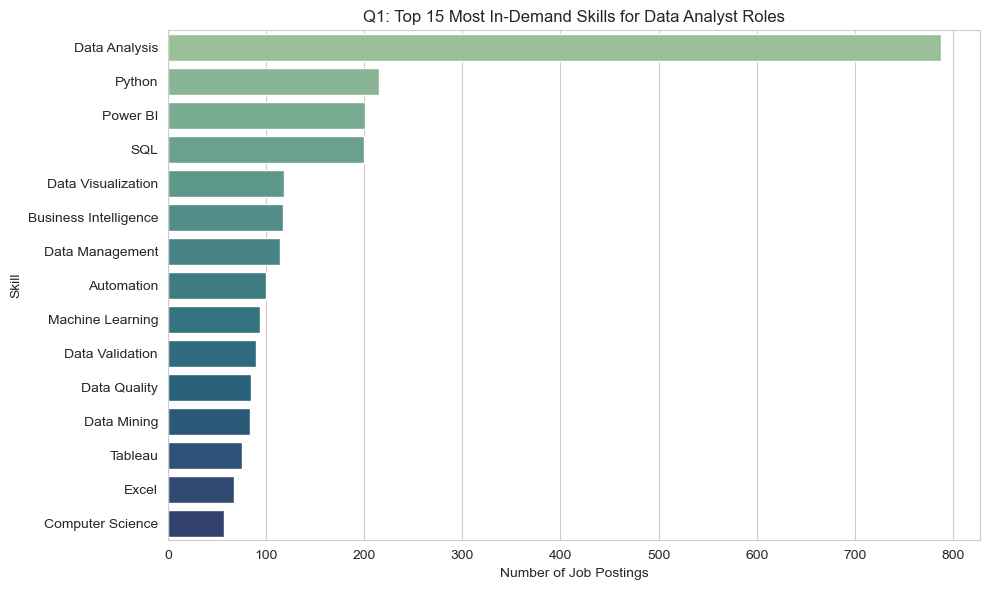

In [93]:
# Q1. What are the most in-demand skills for Data Analyst roles?
# =====================================================
 
# split the skills text into a list again, one row at a time
skills_split = df['skills'].str.split(', ')
 
# explode turns each skill in the list into its own row
skills_exploded = df.assign(skills_split=skills_split).explode('skills_split')
 
# remove leading/trailing spaces
skills_exploded['skills_split'] = skills_exploded['skills_split'].str.strip()
 
# remove the placeholder text we used for missing skills
skills_exploded = skills_exploded[skills_exploded['skills_split'] != 'Not Mentioned']
 
# count the top 15 most common skills
top_skills = skills_exploded['skills_split'].value_counts().head(15)
print(top_skills)
 
# plot bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=top_skills.values, y=top_skills.index, hue=top_skills.index,
            palette='crest', legend=False)
plt.title('Q1: Top 15 Most In-Demand Skills for Data Analyst Roles')
plt.xlabel('Number of Job Postings')
plt.ylabel('Skill')
plt.tight_layout()
plt.savefig('q1_top_skills.png')
plt.show()

min_experience
0     190
1     166
2     190
3     152
4      82
5      88
6      25
7      17
8      45
9       4
10      7
14      1
16      1
20      1
Name: count, dtype: Int64


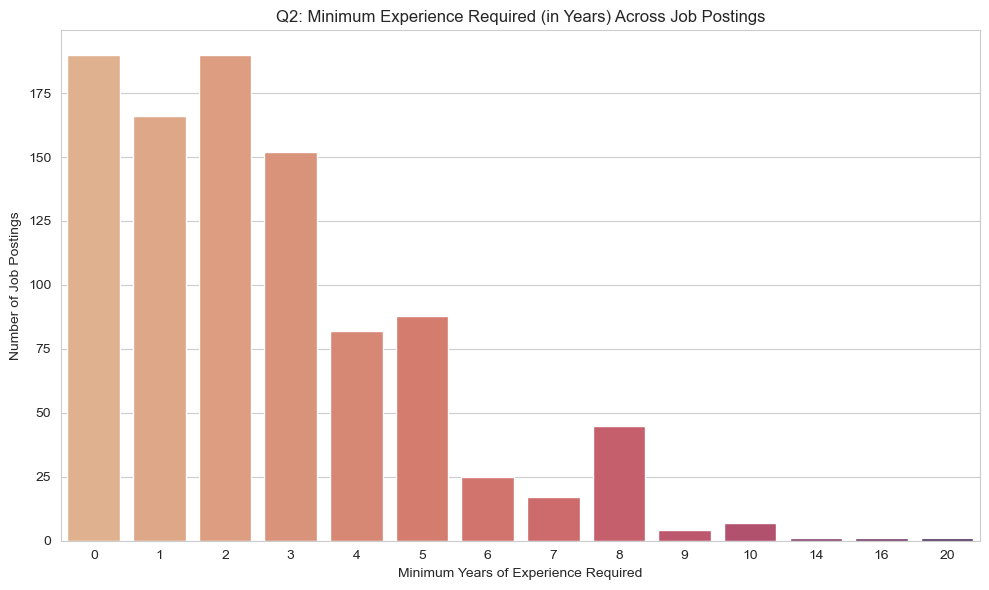

Postings open to freshers (0 years min experience): 190


In [95]:
# Q2. What experience level do most postings require?
# =====================================================
 
# drop rows where min_experience is missing (company didn't mention it)
exp_data = df.dropna(subset=['min_experience'])
 
print(exp_data['min_experience'].value_counts().sort_index())
 
# plot how many postings require each minimum experience level
plt.figure(figsize=(10, 6))
sns.countplot(x='min_experience', data=exp_data, hue='min_experience',
              palette='flare', legend=False)
plt.title('Q2: Minimum Experience Required (in Years) Across Job Postings')
plt.xlabel('Minimum Years of Experience Required')
plt.ylabel('Number of Job Postings')
plt.tight_layout()
plt.savefig('q2_experience_required.png')
plt.show()
 
# quick extra insight: how many postings are fresher-friendly (0 years min)?
fresher_friendly = (exp_data['min_experience'] == 0).sum()
print(f'Postings open to freshers (0 years min experience): {fresher_friendly}')
 

location_split
Bengaluru    247
Pune         160
Hyderabad     97
Mumbai        75
Chennai       74
Gurugram      69
Remote        61
New Delhi     48
Noida         37
Kolkata       32
Name: count, dtype: int64


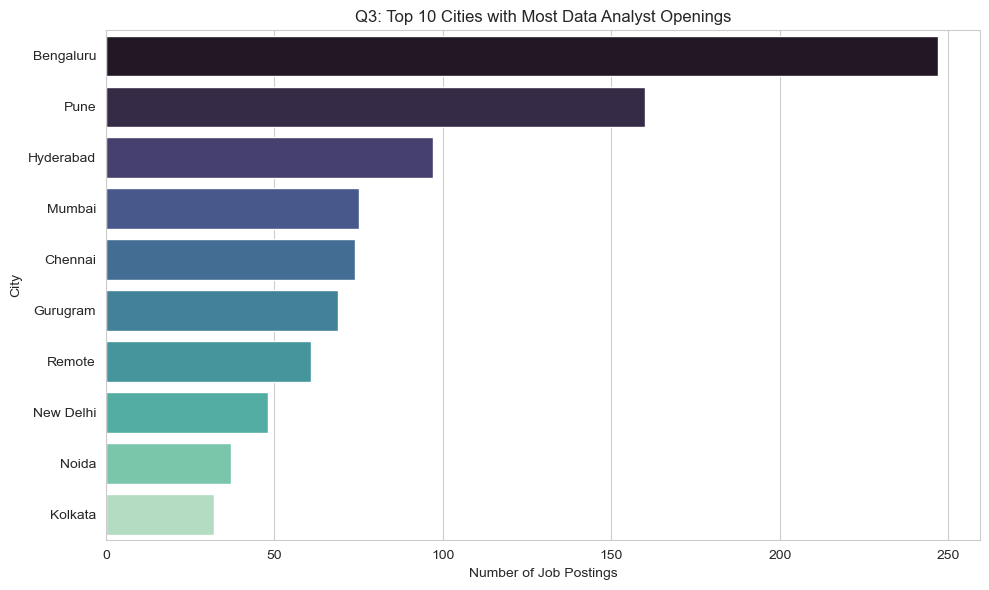

In [97]:
# Q3. Which cities have the most Data Analyst openings?
# =====================================================
 
# split location text into a list again
location_split = df['location'].str.split(', ')
location_exploded = df.assign(location_split=location_split).explode('location_split')
 
# clean extra spaces
location_exploded['location_split'] = location_exploded['location_split'].str.strip()
 
top_locations = location_exploded['location_split'].value_counts().head(10)
print(top_locations)
 
plt.figure(figsize=(10, 6))
sns.barplot(x=top_locations.values, y=top_locations.index, hue=top_locations.index,
            palette='mako', legend=False)
plt.title('Q3: Top 10 Cities with Most Data Analyst Openings')
plt.xlabel('Number of Job Postings')
plt.ylabel('City')
plt.tight_layout()
plt.savefig('q3_top_locations.png')
plt.show()

company
Wipro                            22
Platinus Technologies Pvt Ltd    20
Globant                          18
Peroptyx                         13
Welo Data                        10
Barclays                         10
Axis Max Life Insurance           9
Accenture                         9
eClerx                            9
Dentsu Webchutney                 8
Name: count, dtype: int64


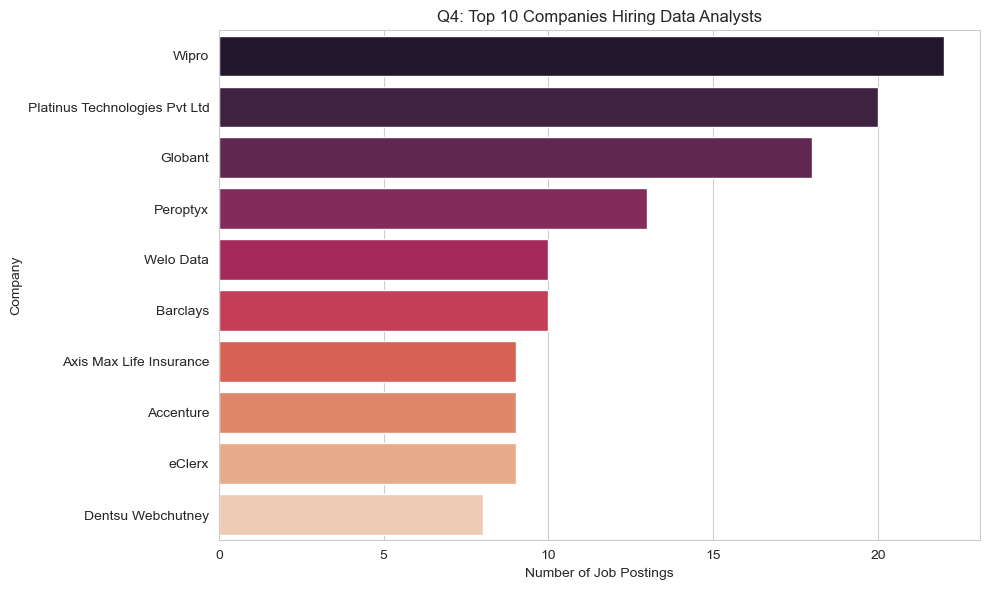

In [99]:
# Q4. Which companies are hiring most aggressively?
# =====================================================
 
top_companies = df['company'].value_counts().head(10)
print(top_companies)
 
plt.figure(figsize=(10, 6))
sns.barplot(x=top_companies.values, y=top_companies.index, hue=top_companies.index,
            palette='rocket', legend=False)
plt.title('Q4: Top 10 Companies Hiring Data Analysts')
plt.xlabel('Number of Job Postings')
plt.ylabel('Company')
plt.tight_layout()
plt.savefig('q4_top_companies.png')
plt.show()

       min_salary  max_salary
count  104.000000  104.000000
mean     6.983173   11.500000
std      5.232143    8.054653
min      1.000000    1.750000
25%      3.000000    5.000000
50%      5.000000    8.875000
75%     10.000000   16.000000
max     25.000000   35.000000


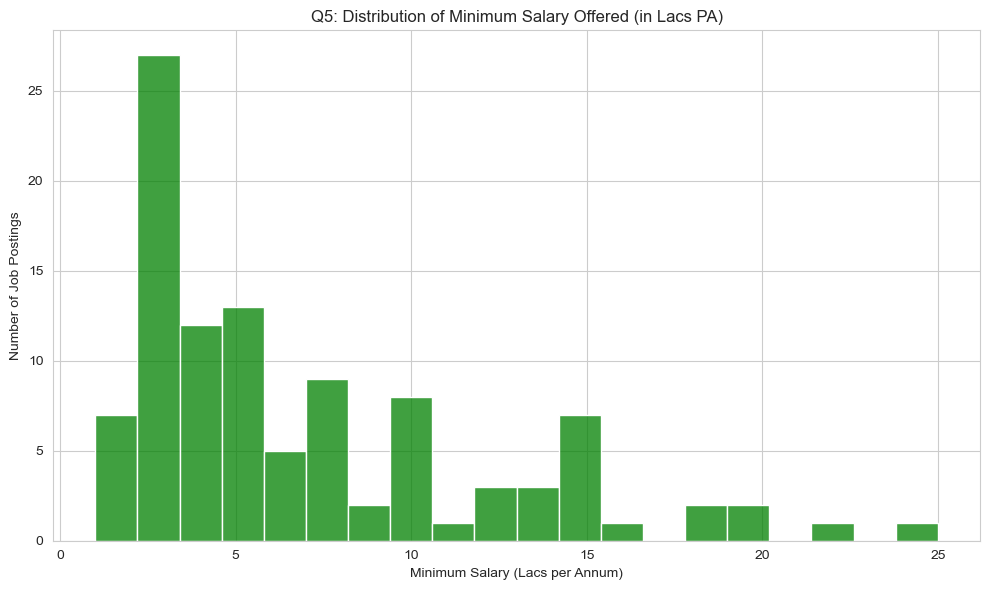

min_experience
0     3.560345
1     2.788462
2     6.056818
3    10.150000
4     9.727273
5     9.600000
6     8.875000
7    18.750000
8    13.000000
9    15.833333
Name: min_salary, dtype: float64


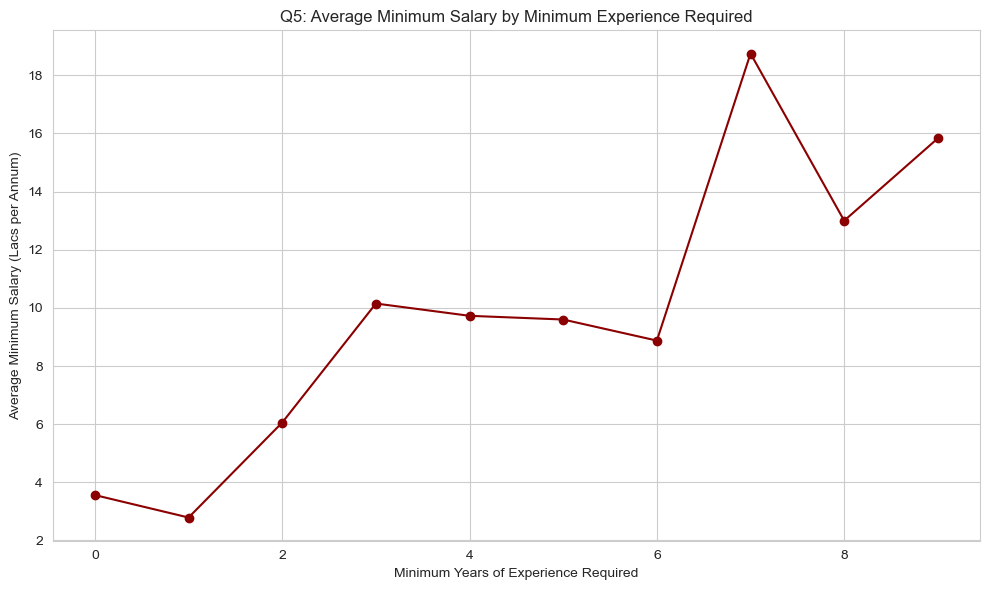

In [103]:
# Q5. Where salary is disclosed, what does it look like,and how does it change with experience?
# =====================================================
 
# only keep rows where salary was given in 'Lacs' format
# (we exclude plain-rupee rows here to avoid mixing units, e.g. 50000 vs 5 Lacs)
salary_data = df[(df['salary_in_lacs'] == True) & (df['min_salary'].notnull())]

salary_data = salary_data[salary_data['min_salary'] <= 100]
 
print(salary_data[['min_salary', 'max_salary']].describe())
 
# plot distribution of minimum salary offered
plt.figure(figsize=(10, 6))
sns.histplot(salary_data['min_salary'], bins=20, color='green')
plt.title('Q5: Distribution of Minimum Salary Offered (in Lacs PA)')
plt.xlabel('Minimum Salary (Lacs per Annum)')
plt.ylabel('Number of Job Postings')
plt.tight_layout()
plt.savefig('q5a_salary_distribution.png')
plt.show()

#plot how average salary changes as minimum experience required increase
avg_salary_by_exp = salary_data.groupby('min_experience')['min_salary'].mean()
print(avg_salary_by_exp)
 
plt.figure(figsize=(10, 6))
plt.plot(avg_salary_by_exp.index, avg_salary_by_exp.values, marker='o', color='darkred')
plt.title('Q5: Average Minimum Salary by Minimum Experience Required')
plt.xlabel('Minimum Years of Experience Required')
plt.ylabel('Average Minimum Salary (Lacs per Annum)')
plt.tight_layout()
plt.savefig('q5b_salary_vs_experience.png')
plt.show()
 

work_mode
On-site    927
Remote      61
Name: count, dtype: int64


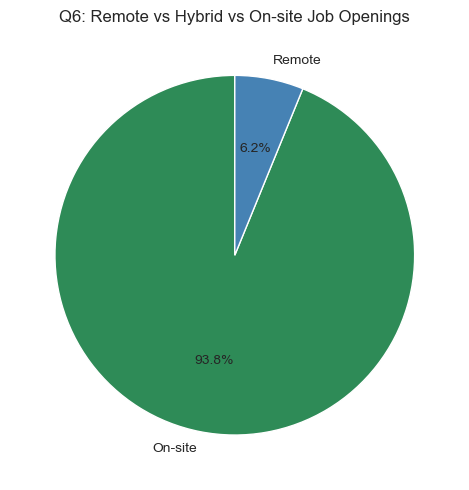

In [107]:
# Q6. What's the split between Remote, Hybrid, and On-site openings?
# =====================================================
 
work_mode_counts = df['work_mode'].value_counts()
print(work_mode_counts)
 
plt.figure(figsize=(5, 5))
colors = ['#2E8B57', '#4682B4', '#CD5C5C']  # green, blue, red
plt.pie(work_mode_counts.values, labels=work_mode_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90)
plt.title('Q6: Remote vs Hybrid vs On-site Job Openings')
plt.tight_layout()
plt.savefig('q6_work_mode_split.png')
plt.show()


In [109]:
print('\n--- SUMMARY ---')
print('Most in-demand skill:', top_skills.index[0])
print('Most common minimum experience required:', exp_data['min_experience'].mode()[0], 'years')
print('Top hiring city:', top_locations.index[0])
print('Top hiring company:', top_companies.index[0])
print('Average minimum salary (where disclosed, in Lacs):', round(salary_data['min_salary'].mean(), 2))
print('Most common work mode:', work_mode_counts.index[0])


--- SUMMARY ---
Most in-demand skill: Data Analysis
Most common minimum experience required: 0 years
Top hiring city: Bengaluru
Top hiring company: Wipro
Average minimum salary (where disclosed, in Lacs): 6.98
Most common work mode: On-site
